In [1]:
# standard python imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# tidy3d imports
import tidy3d as td
import tidy3d.web as web
web.configure(apikey="GoMnpjx6Gxf00bAc6wa2oPoqrR3mbWeYuuyi3aTPF94dR1kO")

from tidy3d import material_library

Configuration saved successfully.


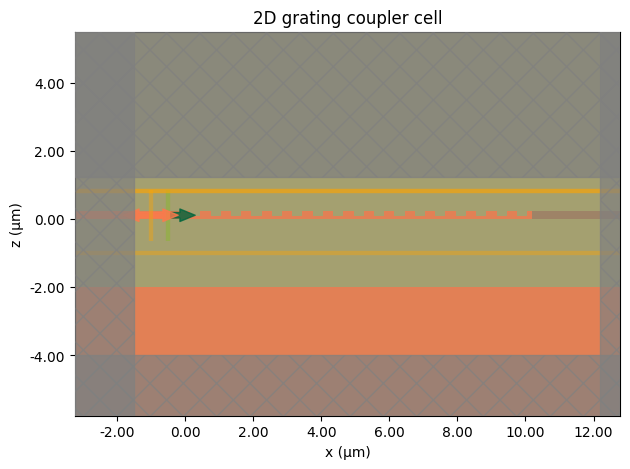

In [10]:
def create_2d_gc_simulation(wl=1.55, wg_thick=0.22, etch_depth=0.13, period=0.6, duty_cycle=0.5, mirror_shift=0.28):
    # paper-inspired 2D grating coupler on SOI
    freq0 = td.C_0 / wl
    wvl0 = td.C_0 / freq0
    fwidth = freq0 / 20
    freqs = np.linspace(freq0 - fwidth, freq0 + fwidth, 51)

    si = material_library['cSi']['Palik_Lossless']
    sio2 = material_library['SiO2']['Palik_Lossless']
    au = material_library['Au']['JohnsonChristy1972']
    air = td.Medium(permittivity=1.0)

    # SOI stack dimensions (micron)
    t_si = wg_thick
    t_box = 2.0
    t_sub = 2.0
    t_clad = 1.0

    # Diameter follows duty_cycle * period, radius is half the diameter.
    hole_diameter = duty_cycle * period
    hole_radius = 0.5 * hole_diameter

    # Match the fiber-core-scale grating length (~10 um).
    grating_length = 10.0
    num_periods = int(np.round(grating_length / period))
    grating_length = num_periods * period
    mirror_thickness_x = 2.0

    # Simulation padding
    buffer = 5.0

    # Input waveguide before grating and continuous slab up to mirror start
    input_wg_length = 1.5
    x_grating_start = 0.0
    x_grating_end = grating_length
    x_slab_start = -input_wg_length
    x_slab_end = x_grating_end + mirror_shift
    x_mirror_start = x_slab_end
    x_mirror_end = x_mirror_start + mirror_thickness_x

    # 3D width in y
    sim_width_y = period

    # Vertical references
    z_si_bottom = 0.0
    z_si_top = z_si_bottom + t_si
    z_box_top = z_si_bottom
    z_box_bottom = z_box_top - t_box
    z_sub_top = z_box_bottom
    z_sub_bottom = z_sub_top - t_sub
    z_clad_top = z_si_top + t_clad
    z_clad_bottom = z_clad_top - t_clad

    # SOI layers
    sio2_clad = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0),
            size=(td.inf, td.inf, td.inf),
        ),
        medium=sio2,
        name='sio2_clad',
    )
    si_substrate = td.Structure(
        geometry=td.Box(
            center=(0, 0, 0.5 * (z_sub_top + z_sub_bottom - buffer)),
            size=(td.inf, td.inf, t_sub + buffer),
        ),
        medium=si,
        name='si_substrate',
    )

    si_slab = td.Structure(
        geometry=td.Box(
            center=(0.5 * (x_slab_start + x_slab_end - buffer), 0, z_si_bottom + t_si / 2),
            size=(x_slab_end - x_slab_start + buffer, td.inf, t_si),
        ),
        medium=si,
        name='si_slab'
    )

    hole_geometries = []
    for i in range(num_periods):
        hole_geometries.append(
            td.Cylinder(
                center=(x_grating_start + (i + 0.5) * period, 0, z_si_top - etch_depth / 2),
                radius=hole_radius,
                length=etch_depth,
                axis=2,
            )
        )

    etch_holes = td.Structure(
        geometry=td.GeometryGroup(geometries=hole_geometries), 
        medium=sio2, 
        name='etch_holes'
    )

    # Au mirror with explicit x-gap from grating end (mirror_shift).
    au_mirror = td.Structure(
        geometry=td.Box(
            center=(0.5 * (x_mirror_start + x_mirror_end + buffer), 0, z_si_bottom + t_si / 2),
            size=(mirror_thickness_x + buffer, td.inf, t_si),
        ),
        medium=au,
        name='au_mirror'
    )

    source = td.ModeSource(
        center=(x_slab_start + 1.0, 0, z_si_bottom + t_si / 2),
        size=(0, td.inf, 1.5),
        direction='+',
        mode_spec=td.ModeSpec(num_modes=1, target_neff=2.8),
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        name='input_source',
    )

    apod = td.ApodizationSpec(
        start=0,          # Window is fully open at the beginning
        end=4.5e-12,      # Start the fade-out at 4.5 ps
        width=0.5e-12     # Make the fade-out take exactly 0.5 ps
    )

    near_field_line = td.FieldMonitor(
        center=(0, 0, z_si_top + 0.6),
        size=(td.inf, 0, 0), # 1D line along X
        freqs=[freq0],
        name="near_field_line"
    )

    # Flux Monitors
    upward_monitor = td.FluxMonitor(
        center=(0.5 * (x_slab_start + x_mirror_end), 0, z_si_top + 0.6),
        size=(td.inf, td.inf, 0),
        freqs=freqs,
        name='upward_flux',
        apodization=apod
    )
    downward_monitor = td.FluxMonitor(
        center=(0.5 * (x_slab_start + x_mirror_end), 0, 0.5 * (z_box_top + z_box_bottom)),
        size=(td.inf, td.inf, 0),
        freqs=freqs,
        name='downward_flux',
        apodization=apod
    )
    backward_monitor = td.ModeMonitor(
        center=(x_slab_start + 0.5, 0, z_si_bottom + t_si / 2),
        size=(0, td.inf, 1.5),
        freqs=freqs,
        name='backward_flux',
        apodization=apod
    )

    # Field Monitors
    fieldxz_monitor = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, 0, td.inf),
        freqs=[freq0],
        name='field_xz',
        apodization=apod
    )

    sim_x_min = x_slab_start
    sim_x_max = x_mirror_end
    sim_center_x = 0.5 * (sim_x_min + sim_x_max)
    sim_size_x = sim_x_max - sim_x_min
    sim_z_min = z_sub_bottom
    sim_z_max = z_clad_top
    sim_center_z = 0.5 * (sim_z_min + sim_z_max)
    sim_size_z = sim_z_max - sim_z_min

    sim = td.Simulation(
        center=(sim_center_x, 0, sim_center_z),
        size=(sim_size_x, sim_width_y, sim_size_z),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=10, wavelength=wvl0),
        structures=[sio2_clad, si_substrate, si_slab, etch_holes, au_mirror],
        sources=[source],
        monitors=[upward_monitor, downward_monitor, backward_monitor, fieldxz_monitor, near_field_line],
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.absorber(),
            y=td.Boundary.periodic(),
            z=td.Boundary.absorber(),
        ),
        # medium=air,
        run_time=5e-12,
        shutoff=1e-5,
    )

    return sim

sim = create_2d_gc_simulation(mirror_shift=0, duty_cycle=0.5)
ax = sim.plot(y=0)
ax.set_title('2D grating coupler cell')
plt.show()

In [11]:
sim.plot_3d()

In [ ]:
period = 0.585
duty_cycle = 0.530
mirror_shift = 0.35

sim = create_2d_gc_simulation(period=period, duty_cycle=duty_cycle, mirror_shift=mirror_shift)
task_id = web.upload(sim, task_name=f"etch_130_d_{duty_cycle}_p_{period}_m_{mirror_shift}", folder_name="2d_gc/cell_test/")
estimate = web.estimate_cost(task_id)

web.start(task_id)
web.monitor(task_id, verbose=True)

sim_data = web.load(task_id, path=f'data/2d_gc/cell_test/d_{duty_cycle}_p_{period}_m_{mirror_shift}.hdf5')

00:51:44 SE Asia Standard Time Created task 'etch_130_d_0.5_p_0.577_m_0.1' with 
                               resource_id                                      
                               'fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=952496;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=592176;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\taskId]8;;\
                               ]8;id=952496;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\=]8;;\]8;id=188783;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\fdve]8;;\]8;id=952496;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\-1a465885-b5d6-42d1-917b-2b06ef3a15ad']8;;\.

                               Task folder: ]8;id=687310;https://tidy3d.simulation.cloud/folders/folder-f8a5ffea-baea-480f-9190-cf0defcc0e87\'default']8;;\.

Output()

00:51:49 SE Asia Standard Time Estimated FlexCredit cost: 0.581. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

...

00:52:56 SE Asia Standard Time early shutoff detected at 72%, exiting.

00:52:57 SE Asia Standard Time status = success

                               View simulation result at                        
                               ]8;id=70378;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=581153;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\taskId]8;;\
                               ]8;id=70378;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\=]8;;\]8;id=582579;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\fdve]8;;\]8;id=70378;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1a465885-b5d6-42d1-917b-2b06ef3a15ad\-1a465885-b5d6-42d1-917b-2b06ef3a15ad']8;;\.

Output()

00:53:08 SE Asia Standard Time Loading results from                             
                               data\2d_gc\cell_test\d_0.5_p_0.577_m_0.1.hdf5

In [39]:
def extract_angle_and_flux(sim_data, wvl_target=1.55, flux_monitor="upward_flux", near_field_monitor="near_field_line"):
    # 1. Get the Upward Flux (Intensity)
    upward_flux = sim_data[flux_monitor].flux.values[0]
    
    # 2. Get the Near-Field data
    line_data = sim_data[near_field_monitor]
    
    # Extract the X coordinates and the complex Ey field
    x_coords = line_data.Ey.coords['x'].values
    Ey_complex = line_data.Ey.squeeze().values
    
    # 3. Perform the Spatial Fourier Transform
    dx = x_coords[1] - x_coords[0] 
    N = len(x_coords)
    
    # Add Zero-Padding to increase angular resolution (10x smoother)
    pad_factor = 10 
    N_padded = N * pad_factor
    
    # Use n=N_padded to tell numpy to automatically pad with zeros
    fft_field = np.fft.fft(Ey_complex, n=N_padded)
    fft_power = np.abs(fft_field)**2
    
    # Ensure the frequency array matches the new padded length
    kx_array = 2 * np.pi * np.fft.fftfreq(N_padded, d=dx)
    
    # Shift arrays so 0 frequency is dead center
    kx_array = np.fft.fftshift(kx_array)
    fft_power = np.fft.fftshift(fft_power)    
    # 4. Find the peak spatial frequency
    peak_idx = np.argmax(fft_power)
    kx_peak = kx_array[peak_idx]
    
    # 5. Convert spatial frequency to geometric angle
    k0 = 2 * np.pi / wvl_target
    
    # Limit kx to physically radiating modes to avoid math domain errors
    kx_peak = np.clip(kx_peak, -k0, k0) 
    
    angle_rad = np.arcsin(kx_peak / k0)
    angle_deg = np.degrees(angle_rad)
    
    return float(angle_deg), float(upward_flux)

angle, flux = extract_angle_and_flux(sim_data)
print(f"Extracted angle: {angle:.2f} degrees")
print(f"Extracted upward flux: {flux:.4e}")

Extracted angle: -3.34 degrees
Extracted upward flux: 4.1081e-01


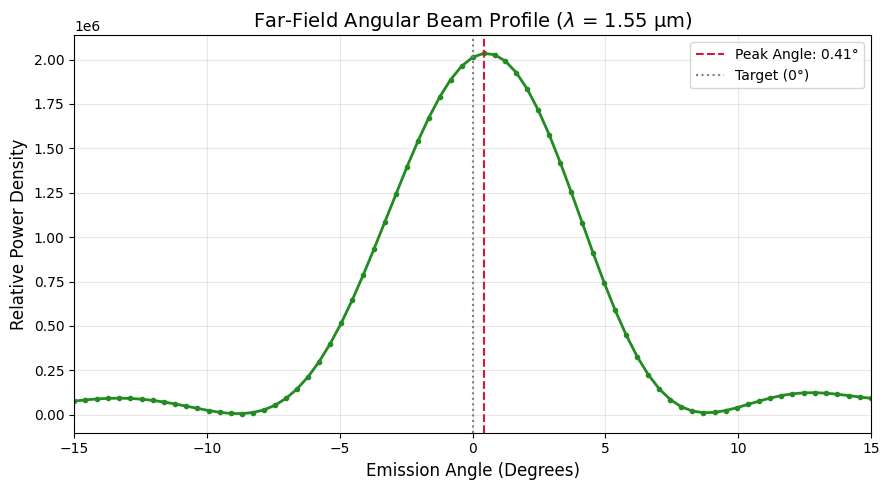

In [ ]:
def plot_angular_emission(sim_data, wvl_target=1.55):
    # 1. Get the Near-Field data
    line_data = sim_data["near_field_line"]
    
    # Extract coordinates and complex Ey
    x_coords = line_data.Ey.coords['x'].values 
    Ey_complex = line_data.Ey.squeeze().values
    
    # 2. Perform the Spatial Fourier Transform
    dx = x_coords[1] - x_coords[0] 
    N = len(x_coords)
    
    # Add Zero-Padding to increase angular resolution (10x smoother)
    pad_factor = 10 
    N_padded = N * pad_factor
    
    # Use n=N_padded to tell numpy to automatically pad with zeros
    fft_field = np.fft.fft(Ey_complex, n=N_padded)
    fft_power = np.abs(fft_field)**2
    
    # Ensure the frequency array matches the new padded length
    kx_array = 2 * np.pi * np.fft.fftfreq(N_padded, d=dx)
    
    # Shift arrays so 0 frequency is dead center
    kx_array = np.fft.fftshift(kx_array)
    fft_power = np.fft.fftshift(fft_power)    
    # 3. Convert spatial frequencies (kx) to Angles (Degrees)
    k0 = 2 * np.pi / wvl_target
    
    # Filter out evanescent modes (light that is trapped and doesn't radiate)
    valid_indices = np.where(np.abs(kx_array) <= k0)
    kx_valid = kx_array[valid_indices]
    power_valid = fft_power[valid_indices]
    
    angles_rad = np.arcsin(kx_valid / k0)
    angles_deg = np.degrees(angles_rad)
    
    # 4. Create the Plot
    fig, ax = plt.subplots(figsize=(9, 5))
    
    # Plot the beam profile
    ax.plot(angles_deg, power_valid, color='forestgreen', linewidth=2, marker='.')
    
    # Find and mark the exact peak
    peak_idx = np.argmax(power_valid)
    peak_angle = angles_deg[peak_idx]
    
    ax.axvline(peak_angle, color='crimson', linestyle='--', 
               label=f'Peak Angle: {peak_angle:.2f}°')
    
    # Draw a reference line for perfectly vertical (0 degrees)
    ax.axvline(0, color='gray', linestyle=':', label='Target (0°)')
    
    # Formatting
    ax.set_title(f'Far-Field Angular Beam Profile ($\\lambda$ = {wvl_target} µm)', fontsize=14)
    ax.set_xlabel('Emission Angle (Degrees)', fontsize=12)
    ax.set_ylabel('Relative Power Density', fontsize=12)
    
    # Zoom in to the relevant angles so the Gaussian is easy to see
    # ax.set_xlim(-15, 15) 
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_angular_emission(sim_data)

In [40]:
def run_optimization_sweep():
    # Period and duty cycle control the effective index, which sets the angle
    periods = np.linspace(0.51, 0.55, 5)
    duty_cycles = [0.500]
    
    # Mirror shift mostly controls the peak intensity (constructive interference)
    mirror_shifts = np.linspace(0.20, 0.35, 5)

    print(f"Building {len(periods) * len(duty_cycles) * len(mirror_shifts)} simulations...")
    
    sim_dict = {}
    for p in periods:
        for d in duty_cycles:
            for m in mirror_shifts:
                sim_name = f"p_{p:.3f}_d_{d:.3f}_m_{m:.3f}"
                sim_dict[sim_name] = create_2d_gc_simulation(period=p, duty_cycle=d, mirror_shift=m)

    print("Submitting batch to Tidy3D...")
    batch = web.Batch(simulations=sim_dict, folder_name="2d_gc/220_1550/period_shift_sweep/", verbose=True)
    batch_results = batch.run(path_dir="data/2d_gc/220_1550/period_shift_sweep/")

    return batch, batch_results

def extract_sweep_data(batch_results, wvl_target=1.55, flux_monitor="upward_flux", near_field_monitor="near_field_line"):
    results = []

    for name, sim_data in batch_results.items():
        # Parse parameters from the simulation name
        # (Assumes your naming convention is e.g., "period_0.53_duty_cycle_0.5_mirror_0.4")
        p = float(name.split('_')[1])
        d = float(name.split('_')[3])
        m = float(name.split('_')[5])

        # 1. Grab the Total Upward Flux 
        # This becomes the 'Peak_Intensity' in the dataframe so your heatmap shows true efficiency
        upward_flux = float(sim_data[flux_monitor].flux.values[0])
        
        # 2. Grab the Near-Field data
        line_data = sim_data[near_field_monitor]
        x_coords = line_data.Ey.coords['x'].values 
        Ey_complex = line_data.Ey.squeeze().values
        
        # 3. Perform the Spatial Fourier Transform WITH ZERO-PADDING
        dx = x_coords[1] - x_coords[0] 
        N = len(x_coords)
        pad_factor = 10  # 10x resolution boost for smooth angles
        N_padded = N * pad_factor
        
        fft_field = np.fft.fft(Ey_complex, n=N_padded)
        fft_power = np.abs(fft_field)**2
        
        kx_array = 2 * np.pi * np.fft.fftfreq(N_padded, d=dx)
        
        # Shift arrays so 0 frequency is dead center
        kx_array = np.fft.fftshift(kx_array)
        fft_power = np.fft.fftshift(fft_power)
        
        # 4. Find the peak angle
        k0 = 2 * np.pi / wvl_target
        
        # Filter out trapped evanescent light
        valid_indices = np.where(np.abs(kx_array) <= k0)
        kx_valid = kx_array[valid_indices]
        power_valid = fft_power[valid_indices]
        
        peak_idx = np.argmax(power_valid)
        kx_peak = kx_valid[peak_idx]
        
        angle_rad = np.arcsin(kx_peak / k0)
        angle_deg = np.degrees(angle_rad)

        # 5. Append to results using your original column names
        results.append({
            'Period': p, 
            'Duty_Cycle': d,
            'Mirror_Shift': m, 
            'Angle_Deg': float(angle_deg), 
            'Peak_Intensity': upward_flux 
        })

    # Convert to DataFrame for easy viewing/sorting
    df = pd.DataFrame(results)
    
    # Sort to find the angle closest to 0
    df['Angle_Error'] = df['Angle_Deg'].abs()
    best_designs = df.sort_values(by=['Angle_Error', 'Peak_Intensity'], ascending=[True, False])
    
    print("\nTop 5 Designs (Closest to 0 degrees):")
    print(best_designs.head())
    
    return best_designs

# Run the sweep
batch, batch_results = run_optimization_sweep()
optimized_data = extract_sweep_data(batch_results)

Building 25 simulations...
Submitting batch to Tidy3D...


Output()

00:58:31 SE Asia Standard Time Started working on Batch containing 25 tasks.

00:59:13 SE Asia Standard Time Maximum FlexCredit cost: 14.211 for the whole    
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after completion.

Output()

01:01:53 SE Asia Standard Time Batch complete.


Top 5 Designs (Closest to 0 degrees):
    Period  Duty_Cycle  Mirror_Shift  Angle_Deg  Peak_Intensity  Angle_Error
24    0.55         0.5         0.350  -6.621029        0.371401     6.621029
23    0.55         0.5         0.312  -7.051456        0.363796     7.051456
22    0.55         0.5         0.275  -7.066100        0.348174     7.066100
21    0.55         0.5         0.237  -7.066100        0.334049     7.066100
20    0.55         0.5         0.200  -7.499649        0.326083     7.499649



Top 5 Designs (Closest to 0 degrees):
    Period  Duty_Cycle  Mirror_Shift  Angle_Deg  Peak_Intensity  Angle_Error
10   0.585        0.53         0.414   0.410371        0.444806     0.410371
11   0.585        0.53         0.436   0.410371        0.435667     0.410371
8    0.585        0.53         0.371   0.411212        0.453161     0.411212
9    0.585        0.53         0.393   0.411212        0.451016     0.411212
7    0.585        0.53         0.350   0.412056        0.449742     0.412056


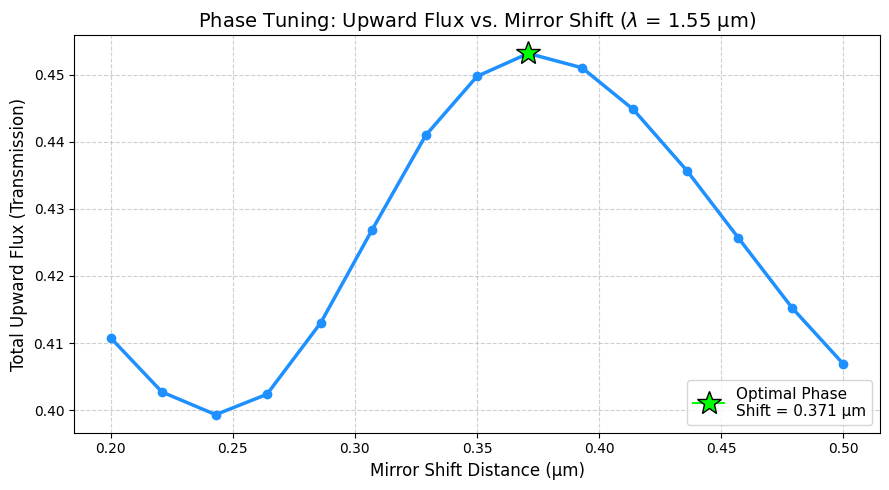

In [35]:
import matplotlib.pyplot as plt

def plot_1d_mirror_sweep(df):
    # Sort the dataframe by mirror shift so the line draws smoothly left-to-right
    df_sorted = df.sort_values(by='Mirror_Shift')
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 5))
    
    # Plot the phase tuning curve
    ax.plot(df_sorted['Mirror_Shift'], df_sorted['Peak_Intensity'], 
            marker='o', linestyle='-', color='dodgerblue', linewidth=2.5)
    
    # Find and prominently mark the absolute peak
    best_point = df_sorted.loc[df_sorted['Peak_Intensity'].idxmax()]
    
    ax.plot(best_point['Mirror_Shift'], best_point['Peak_Intensity'], 
            marker='*', color='lime', markersize=18, 
            markeredgecolor='black', 
            label=f"Optimal Phase\nShift = {best_point['Mirror_Shift']:.3f} µm")

    # Formatting
    ax.set_title('Phase Tuning: Upward Flux vs. Mirror Shift ($\\lambda$ = 1.55 µm)', fontsize=14)
    ax.set_xlabel('Mirror Shift Distance (µm)', fontsize=12)
    ax.set_ylabel('Total Upward Flux (Transmission)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Execution
df_1d = extract_sweep_data(batch_results)
plot_1d_mirror_sweep(df_1d)

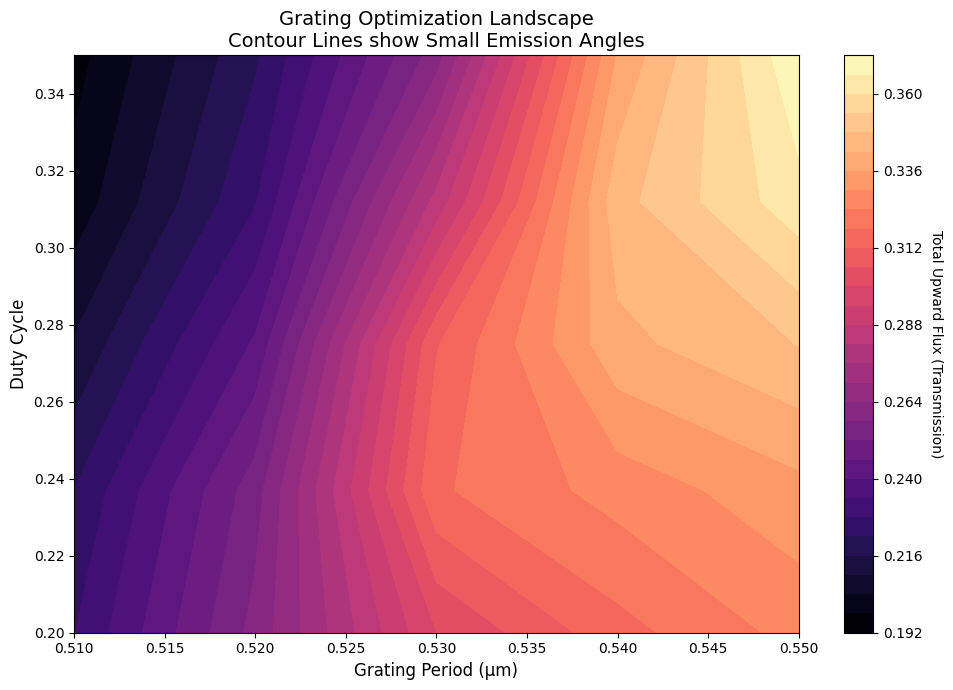

In [41]:
def plot_optimization_landscape(df):
    # 1. Reshape the flat dataframe back into a 2D grid
    grid_intensity = df.pivot(index='Mirror_Shift', columns='Period', values='Peak_Intensity')
    grid_angle = df.pivot(index='Mirror_Shift', columns='Period', values='Angle_Deg')
    
    # Extract the X (Period) and Y (Duty Cycle) axes
    X = grid_intensity.columns.values
    Y = grid_intensity.index.values
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # 2. Plot the Total Flux as a colored contour map (Heatmap)
    contour_flux = ax.contourf(X, Y, grid_intensity.values, levels=30, cmap='magma')
    cbar = fig.colorbar(contour_flux, ax=ax)
    # Updated label to reflect that this is now true transmission flux
    cbar.set_label('Total Upward Flux (Transmission)', rotation=270, labelpad=15)
    
    # 3. Overlay the Emission Angle contours
    contour_zero_angle = ax.contour(X, Y, grid_angle.values, levels=[0.0], colors='cyan', linewidths=3)
    
    # Add some context lines for angles slightly off-center
    ax.contour(X, Y, grid_angle.values, levels=[-2, -1, 1, 2], colors='white', linewidths=0.8, linestyles='dashed', alpha=0.5)

    # 4. Find and mark the absolute best point
    valid_angles = df[df['Angle_Deg'].abs() <= 0.5]
    if not valid_angles.empty:
        best_point = valid_angles.loc[valid_angles['Peak_Intensity'].idxmax()]
        
        ax.plot(best_point['Period'], best_point['Mirror_Shift'], 
                marker='*', color='lime', markersize=15, 
                markeredgecolor='black', label=f"Optimum\n({best_point['Angle_Deg']:.2f}°)")
        ax.legend(loc='upper right')

    # Formatting
    ax.set_title('Grating Optimization Landscape\nContour Lines show Small Emission Angles', fontsize=14)
    ax.set_xlabel('Grating Period (µm)', fontsize=12)
    ax.set_ylabel('Duty Cycle', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Call this function passing in your sorted dataframe from the sweep
plot_optimization_landscape(optimized_data)

In [ ]:
sim_data = td.SimulationData.from_file("data/2d_gc_test/etch_0.07_v2.hdf5")
sim_data.plot_field("field_xz", "E", "abs")

In [15]:
batch.real_cost()

00:00:33 SE Asia Standard Time Total billed flex credit cost: 12.070.

12.069598921465918